In [4]:
import numpy as np
import cv2
import matplotlib.pyplot as quan  # Đổi tên plt thành quan theo yêu cầu
import os
import warnings
warnings.filterwarnings('ignore')


1. ĐỌC VÀ HIỂN THỊ ẢNH GỐC
Kích thước ảnh: (315, 626, 3)
Loại ảnh: uint8
Giá trị pixel min-max: 0 - 255


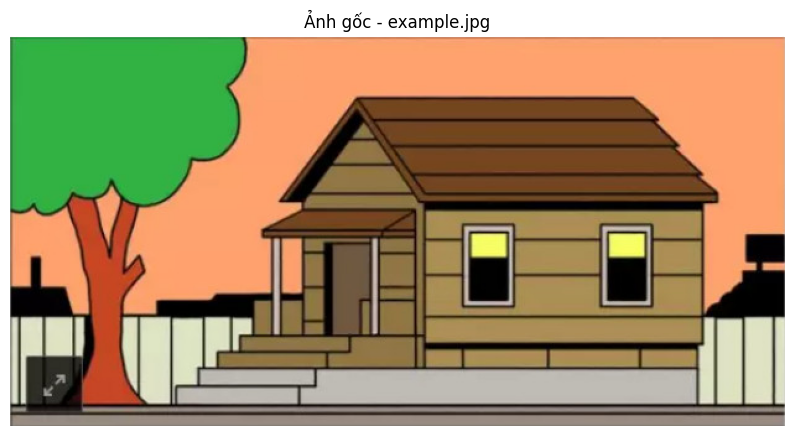


Tạo ảnh thứ hai từ ảnh gốc...
Đã tạo ảnh thứ hai với phép dịch chuyển nhẹ.


In [13]:
# 2. HÀM HIỂN THỊ ẢNH (thay thế cho cv2_imshow của Colab)
def quan_imshow(img, title=None):
    """Hiển thị ảnh bằng matplotlib"""
    if len(img.shape) == 3:
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        quan.imshow(img_rgb)
    else:
        quan.imshow(img, cmap='gray')
    if title:
        quan.title(title)
    quan.axis('off')

# Đọc ảnh từ file example.jpg
print("\n1. ĐỌC VÀ HIỂN THỊ ẢNH GỐC")
img = cv2.imread('example.jpg')
if img is None:
    print("Không thể đọc ảnh 'example.jpg'. Đang tạo ảnh mẫu...")
    # Tạo ảnh mẫu nếu không có ảnh
    img = np.zeros((400, 400, 3), dtype=np.uint8)
    # Vẽ hình học
    cv2.rectangle(img, (50, 50), (350, 350), (0, 255, 0), -1)
    cv2.circle(img, (200, 200), 100, (255, 0, 0), -1)
    cv2.line(img, (50, 50), (350, 350), (0, 0, 255), 5)
    cv2.putText(img, 'LAB 04', (120, 200), cv2.FONT_HERSHEY_SIMPLEX, 2, (255, 255, 255), 3)
    print("Đã tạo ảnh mẫu thay thế.")

print("Kích thước ảnh:", img.shape)
print("Loại ảnh:", img.dtype)
print("Giá trị pixel min-max:", img.min(), "-", img.max())

quan.figure(figsize=(10, 8))
quan_imshow(img, 'Ảnh gốc - example.jpg')
quan.show()

# Tạo ảnh thứ hai ngay từ đầu để sử dụng cho các phần sau
print("\nTạo ảnh thứ hai từ ảnh gốc...")
h, w = img.shape[:2]
M = np.float32([[1, 0, 30], [0, 1, 10]])  # Ma trận dịch chuyển
img2 = cv2.warpAffine(img, M, (w, h))
print("Đã tạo ảnh thứ hai với phép dịch chuyển nhẹ.")


2. HARRIS CORNER DETECTION


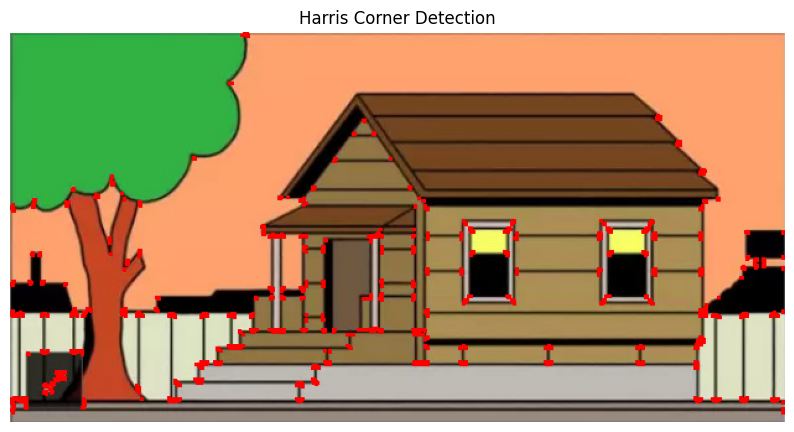

Số lượng corner phát hiện: 5510


In [14]:
# 2. HARRIS CORNER DETECTION
print("\n2. HARRIS CORNER DETECTION")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray = np.float32(gray)

# Harris corner detection
dst = cv2.cornerHarris(gray, 2, 3, 0.04)
dst = cv2.dilate(dst, None)

# Threshold để đánh dấu corner
img_harris = img.copy()
img_harris[dst > 0.01 * dst.max()] = [0, 0, 255]

quan.figure(figsize=(10, 8))
quan_imshow(img_harris, 'Harris Corner Detection')
quan.show()

print(f"Số lượng corner phát hiện: {np.sum(dst > 0.01 * dst.max())}")



3. DIFFERENCE OF GAUSSIANS (DoG)


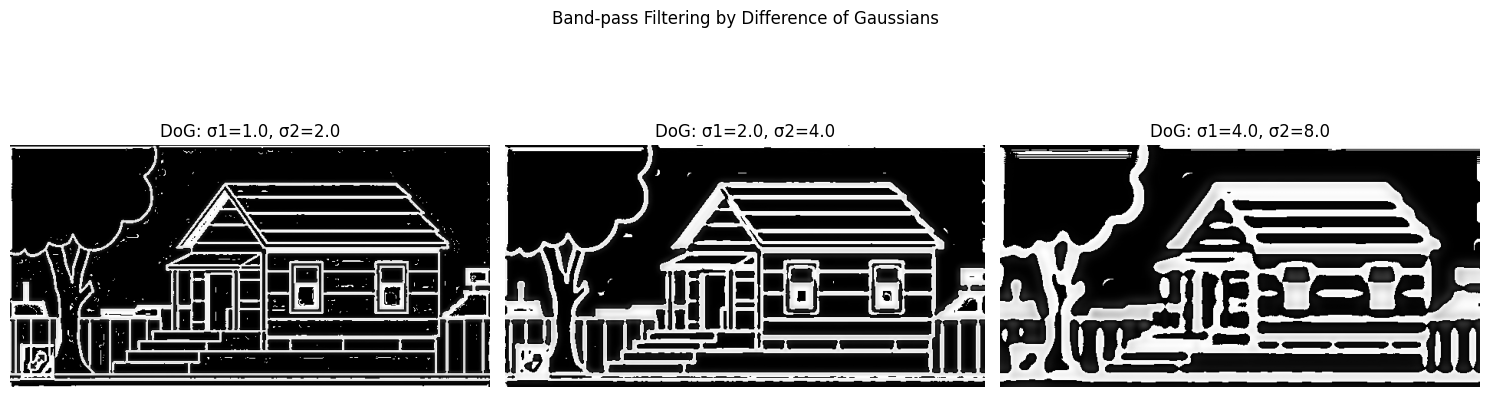

In [15]:
# 3. BAND-PASS FILTERING BY DIFFERENCE OF GAUSSIANS (DoG)
print("\n3. DIFFERENCE OF GAUSSIANS (DoG)")

def difference_of_gaussians(image, sigma1, sigma2):
    """Tính Difference of Gaussians với hai sigma khác nhau"""
    gauss1 = cv2.GaussianBlur(image, (0, 0), sigma1)
    gauss2 = cv2.GaussianBlur(image, (0, 0), sigma2)
    dog = gauss1 - gauss2
    return dog

# Chuyển sang ảnh xám
gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Tính DoG với các sigma khác nhau
sigma_pairs = [(1.0, 2.0), (2.0, 4.0), (4.0, 8.0)]

quan.figure(figsize=(15, 5))
for i, (s1, s2) in enumerate(sigma_pairs):
    dog = difference_of_gaussians(gray_img, s1, s2)
    
    quan.subplot(1, 3, i+1)
    quan.imshow(dog, cmap='gray')
    quan.title(f'DoG: σ1={s1}, σ2={s2}')
    quan.axis('off')

quan.suptitle('Band-pass Filtering by Difference of Gaussians')
quan.tight_layout()
quan.show()



4. AUTOMATIC SCALE SELECTION


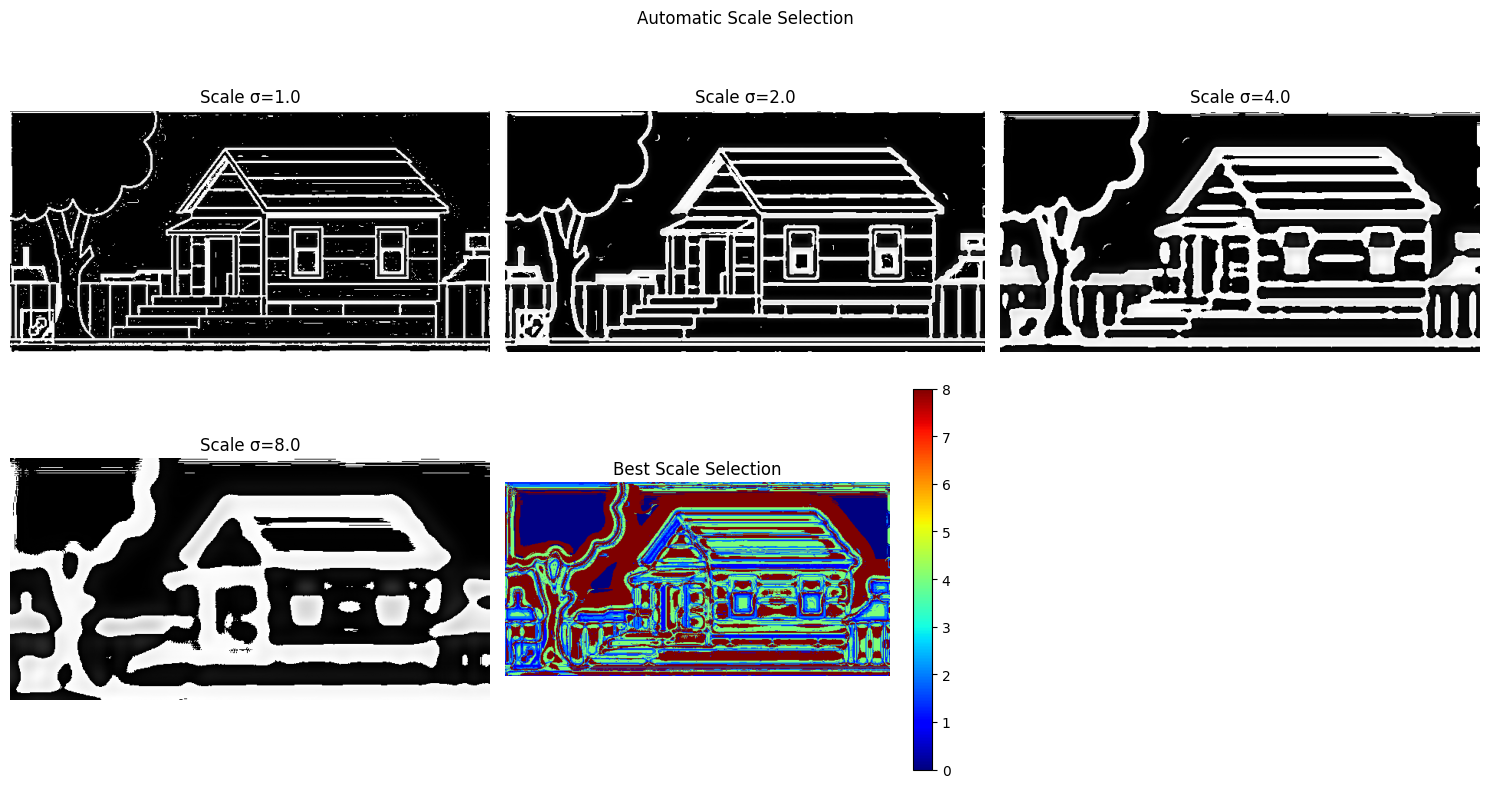

In [16]:
# 4. AUTOMATIC SCALE SELECTION
print("\n4. AUTOMATIC SCALE SELECTION")

def automatic_scale_selection(image, scales):
    """Tự động chọn scale dựa trên Laplacian of Gaussian"""
    responses = []
    
    for sigma in scales:
        # Tính LoG xấp xỉ bằng Difference of Gaussians
        k = 1.6  # Hệ số scale
        gauss1 = cv2.GaussianBlur(image, (0, 0), sigma)
        gauss2 = cv2.GaussianBlur(image, (0, 0), sigma * k)
        log_approx = gauss1 - gauss2
        
        # Chuẩn hóa response
        log_approx = cv2.normalize(log_approx, None, 0, 255, cv2.NORM_MINMAX)
        responses.append(log_approx)
    
    # Tìm scale tốt nhất cho từng pixel
    best_scales = np.zeros_like(image)
    best_responses = np.zeros_like(image, dtype=float)
    
    for i, response in enumerate(responses):
        mask = response > best_responses
        best_responses[mask] = response[mask]
        best_scales[mask] = scales[i]
    
    return best_scales, responses

scales = [1.0, 2.0, 4.0, 8.0]
best_scales, scale_responses = automatic_scale_selection(gray_img, scales)

quan.figure(figsize=(15, 8))
for i, (response, scale) in enumerate(zip(scale_responses, scales)):
    quan.subplot(2, 3, i+1)
    quan.imshow(response, cmap='gray')
    quan.title(f'Scale σ={scale}')
    quan.axis('off')

quan.subplot(2, 3, 5)
im = quan.imshow(best_scales, cmap='jet')
quan.title('Best Scale Selection')
quan.colorbar(im)
quan.axis('off')

quan.suptitle('Automatic Scale Selection')
quan.tight_layout()
quan.show()


5. SCALE INVARIANT DETECTION


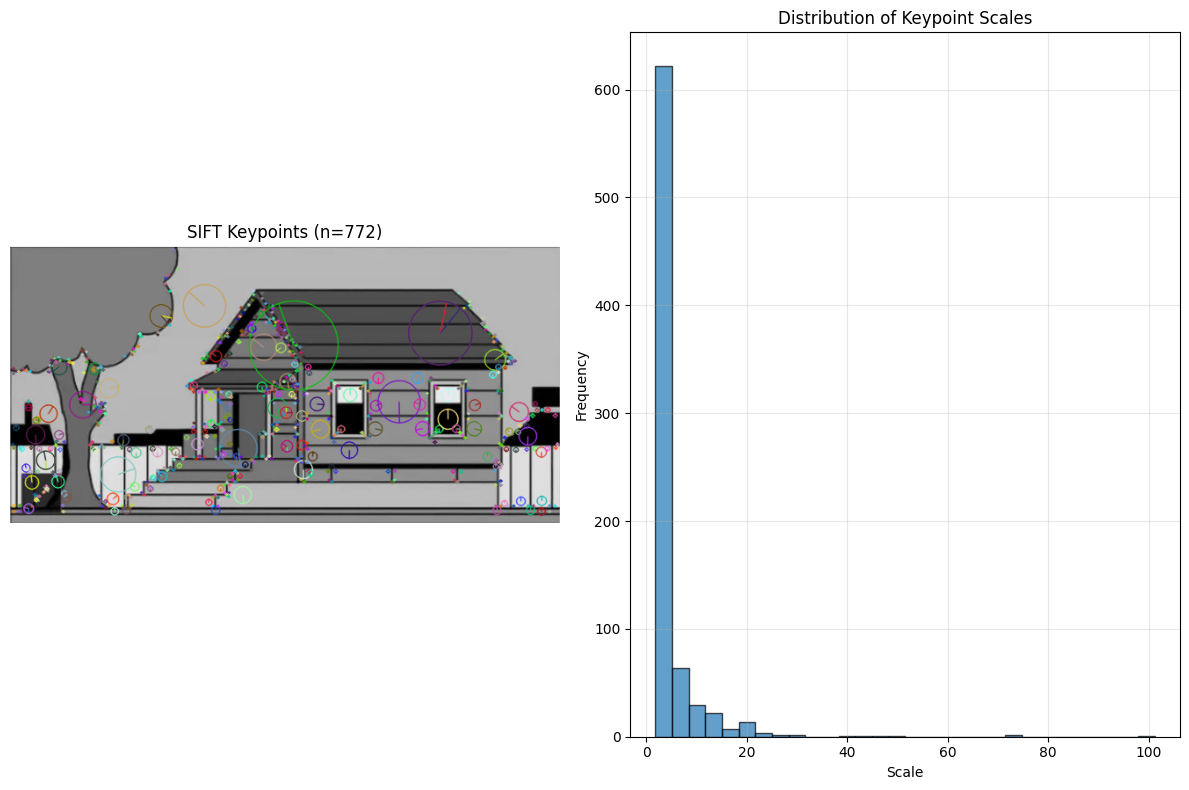

Số lượng SIFT keypoints: 772
Kích thước descriptors: (772, 128)


In [17]:
# 5. SCALE INVARIANT DETECTION
print("\n5. SCALE INVARIANT DETECTION")

# Sử dụng SIFT (Scale-Invariant Feature Transform)
sift = cv2.SIFT_create()
keypoints, descriptors = sift.detectAndCompute(gray_img, None)

# Vẽ keypoints
img_sift = cv2.drawKeypoints(gray_img, keypoints, None, 
                              flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

quan.figure(figsize=(12, 8))
quan.subplot(1, 2, 1)
quan_imshow(img_sift, f'SIFT Keypoints (n={len(keypoints)})')

# Hiển thị scale của các keypoints
scales = [kp.size for kp in keypoints]
quan.subplot(1, 2, 2)
quan.hist(scales, bins=30, edgecolor='black', alpha=0.7)
quan.title('Distribution of Keypoint Scales')
quan.xlabel('Scale')
quan.ylabel('Frequency')
quan.grid(True, alpha=0.3)

quan.tight_layout()
quan.show()

print(f"Số lượng SIFT keypoints: {len(keypoints)}")
if descriptors is not None:
    print(f"Kích thước descriptors: {descriptors.shape}")



6. SCALE-SPACE BLOB DETECTOR


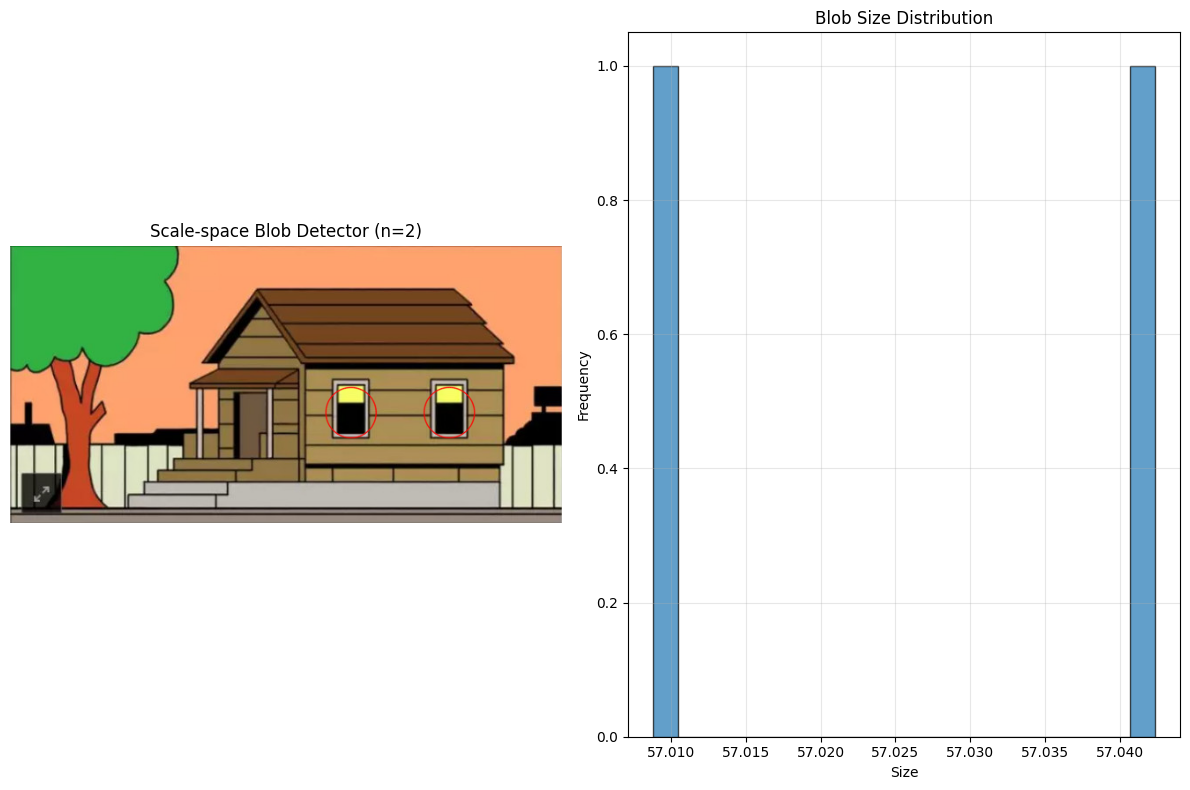

Số lượng blobs phát hiện: 2


In [18]:
# 6. SCALE-SPACE BLOB DETECTOR
print("\n6. SCALE-SPACE BLOB DETECTOR")

# Sử dụng SimpleBlobDetector
params = cv2.SimpleBlobDetector_Params()

# Thiết lập tham số
params.filterByArea = True
params.minArea = 100
params.maxArea = 5000

params.filterByCircularity = True
params.minCircularity = 0.1

params.filterByConvexity = True
params.minConvexity = 0.5

params.filterByInertia = True
params.minInertiaRatio = 0.1

# Tạo detector
detector = cv2.SimpleBlobDetector_create(params)

# Phát hiện blobs
keypoints_blob = detector.detect(gray_img)

# Vẽ blobs
img_blob = cv2.drawKeypoints(img, keypoints_blob, None, (0, 0, 255),
                              cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

quan.figure(figsize=(12, 8))
quan.subplot(1, 2, 1)
quan_imshow(img_blob, f'Scale-space Blob Detector (n={len(keypoints_blob)})')

# Hiển thị kích thước blobs
blob_sizes = [kp.size for kp in keypoints_blob]
quan.subplot(1, 2, 2)
if blob_sizes:
    quan.hist(blob_sizes, bins=20, edgecolor='black', alpha=0.7)
    quan.title('Blob Size Distribution')
    quan.xlabel('Size')
    quan.ylabel('Frequency')
    quan.grid(True, alpha=0.3)
else:
    quan.text(0.5, 0.5, 'No blobs detected', ha='center', va='center', fontsize=12)
    quan.title('Blob Size Distribution')

quan.tight_layout()
quan.show()

print(f"Số lượng blobs phát hiện: {len(keypoints_blob)}")



7. BAG-OF-WORDS DETECTION


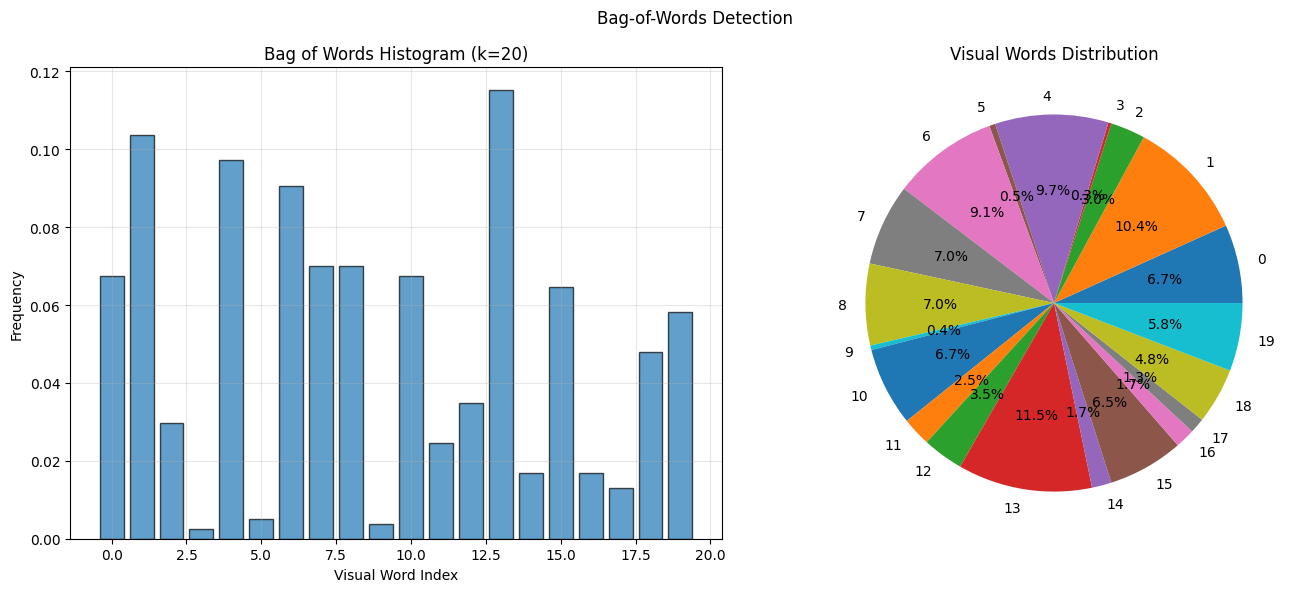

Tổng số visual words: 20
Histogram shape: (20,)


In [19]:
# 7. BAG-OF-WORDS DETECTION
print("\n7. BAG-OF-WORDS DETECTION")

# Tạo Bag of Words với SIFT
def create_bag_of_words(image, n_clusters=30):
    """Tạo Bag of Words từ ảnh sử dụng SIFT"""
    # Phát hiện keypoints và descriptors
    sift = cv2.SIFT_create()
    keypoints, descriptors = sift.detectAndCompute(image, None)
    
    if descriptors is None or len(descriptors) < n_clusters:
        return None, None
    
    # Sử dụng K-means để tạo từ điển visual words
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 10, 1.0)
    _, labels, centers = cv2.kmeans(descriptors.astype(np.float32), n_clusters, None, 
                                     criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
    
    # Tạo histogram
    hist = np.zeros(n_clusters)
    for label in labels.flatten():
        hist[label] += 1
    
    # Chuẩn hóa histogram
    hist = hist / np.sum(hist)
    
    return hist, centers

# Tạo Bag of Words
n_clusters = 20
bow_hist, centers = create_bag_of_words(gray_img, n_clusters)

if bow_hist is not None:
    quan.figure(figsize=(14, 6))
    
    quan.subplot(1, 2, 1)
    quan.bar(range(n_clusters), bow_hist, edgecolor='black', alpha=0.7)
    quan.title(f'Bag of Words Histogram (k={n_clusters})')
    quan.xlabel('Visual Word Index')
    quan.ylabel('Frequency')
    quan.grid(True, alpha=0.3)
    
    quan.subplot(1, 2, 2)
    quan.pie(bow_hist, labels=range(n_clusters), autopct='%1.1f%%')
    quan.title('Visual Words Distribution')
    
    quan.suptitle('Bag-of-Words Detection')
    quan.tight_layout()
    quan.show()
    
    print(f"Tổng số visual words: {n_clusters}")
    print(f"Histogram shape: {bow_hist.shape}")
else:
    print("Không đủ descriptors để tạo Bag of Words")



8. IMAGE PANORAMAS
Số lượng good matches: 709


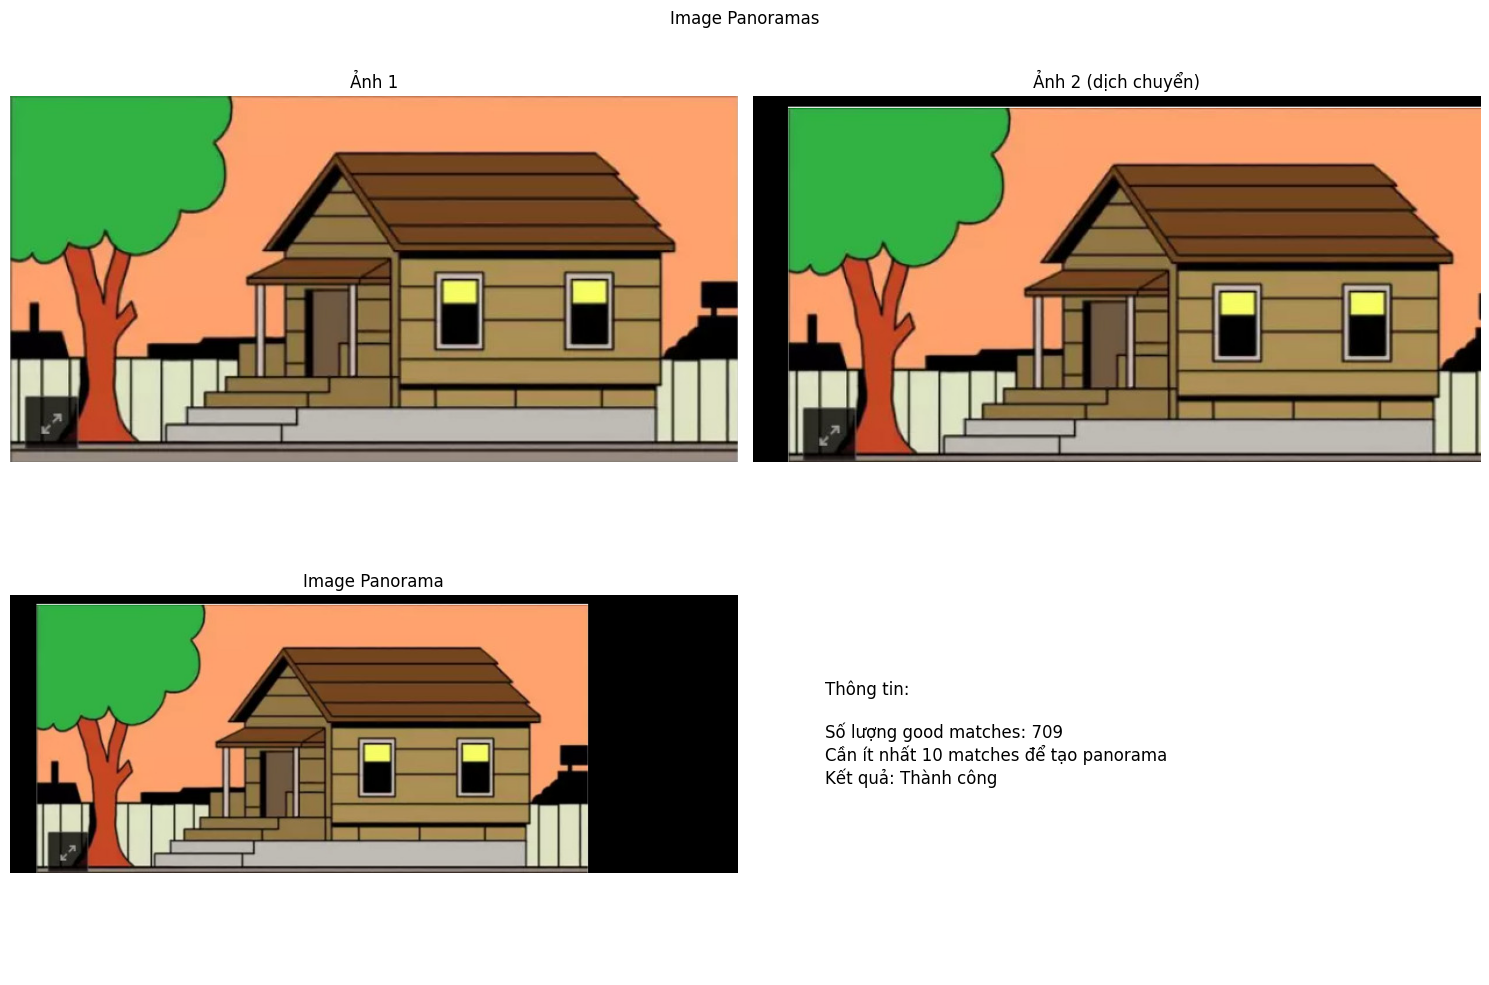

In [20]:
# 8. IMAGE PANORAMAS
print("\n8. IMAGE PANORAMAS")

def create_panorama(img1, img2):
    """Tạo panorama từ hai ảnh"""
    # Chuyển sang ảnh xám
    gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
    gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)
    
    # Tìm keypoints và descriptors
    sift = cv2.SIFT_create()
    kp1, des1 = sift.detectAndCompute(gray1, None)
    kp2, des2 = sift.detectAndCompute(gray2, None)
    
    # Matching descriptors
    bf = cv2.BFMatcher()
    matches = bf.knnMatch(des1, des2, k=2)
    
    # Lowe's ratio test
    good_matches = []
    for match_pair in matches:
        if len(match_pair) == 2:
            m, n = match_pair
            if m.distance < 0.75 * n.distance:
                good_matches.append(m)
    
    print(f"Số lượng good matches: {len(good_matches)}")
    
    if len(good_matches) > 10:
        # Tìm homography
        src_pts = np.float32([kp1[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
        dst_pts = np.float32([kp2[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)
        
        M, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)
        
        if M is not None:
            # Warp ảnh
            h, w = img1.shape[:2]
            result = cv2.warpPerspective(img1, M, (w + 200, h))
            result[0:h, 0:w] = img2
            return result, good_matches
    
    return None, good_matches

# Tạo panorama
panorama, good_matches = create_panorama(img, img2)

quan.figure(figsize=(15, 10))
quan.subplot(2, 2, 1)
quan_imshow(img, 'Ảnh 1')

quan.subplot(2, 2, 2)
quan_imshow(img2, 'Ảnh 2 (dịch chuyển)')

quan.subplot(2, 2, 3)
if panorama is not None:
    quan_imshow(panorama, 'Image Panorama')
else:
    # Hiển thị số lượng matches
    blank = np.zeros((300, 300, 3), dtype=np.uint8)
    cv2.putText(blank, f'Good matches: {len(good_matches)}', (30, 150), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)
    cv2.putText(blank, 'Cannot create panorama', (30, 180), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)
    quan_imshow(blank, 'Không thể tạo panorama')

# Hiển thị thông tin
quan.subplot(2, 2, 4)
quan.axis('off')
info_text = f"Thông tin:\n\n"
info_text += f"Số lượng good matches: {len(good_matches)}\n"
info_text += f"Cần ít nhất 10 matches để tạo panorama\n"
info_text += f"Kết quả: {'Thành công' if panorama is not None else 'Thất bại'}"
quan.text(0.1, 0.5, info_text, fontsize=12, verticalalignment='center')

quan.suptitle('Image Panoramas')
quan.tight_layout()
quan.show()



9. AUTOMATIC MOSAICING
Tạo mosaic thành công!
Kích thước ảnh mosaic: (325, 656, 3)


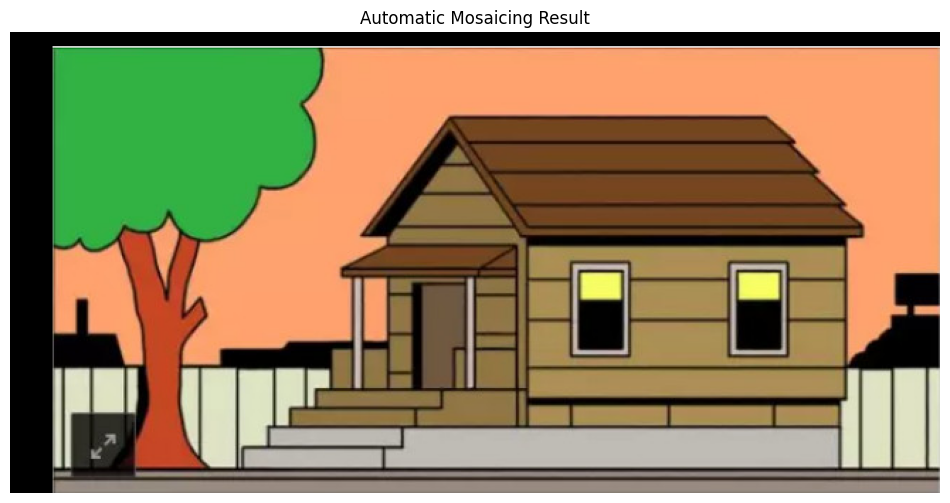

In [21]:
# 9. AUTOMATIC MOSAICING
print("\n9. AUTOMATIC MOSAICING")

def automatic_mosaicing(img1, img2):
    """Tự động ghép ảnh với nhiều bước xử lý"""
    # Chuyển sang ảnh xám
    gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
    gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)
    
    # Phát hiện keypoints với ORB (nhanh hơn SIFT)
    orb = cv2.ORB_create()
    kp1, des1 = orb.detectAndCompute(gray1, None)
    kp2, des2 = orb.detectAndCompute(gray2, None)
    
    # Matching
    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
    matches = bf.match(des1, des2)
    matches = sorted(matches, key=lambda x: x.distance)
    
    # Lấy top matches
    good_matches = matches[:min(50, len(matches))]
    
    if len(good_matches) > 10:
        # Tìm homography
        src_pts = np.float32([kp1[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
        dst_pts = np.float32([kp2[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)
        
        M, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)
        
        if M is not None:
            # Tạo ảnh panorama với blending
            h1, w1 = img1.shape[:2]
            h2, w2 = img2.shape[:2]
            
            # Tính kích thước panorama
            pts1 = np.float32([[0, 0], [0, h1], [w1, h1], [w1, 0]]).reshape(-1, 1, 2)
            pts2 = np.float32([[0, 0], [0, h2], [w2, h2], [w2, 0]]).reshape(-1, 1, 2)
            pts2_trans = cv2.perspectiveTransform(pts2, M)
            
            all_pts = np.concatenate((pts1, pts2_trans), axis=0)
            [xmin, ymin] = np.int32(all_pts.min(axis=0).ravel() - 0.5)
            [xmax, ymax] = np.int32(all_pts.max(axis=0).ravel() + 0.5)
            
            # Dịch chuyển để tránh giá trị âm
            translation_dist = [-xmin, -ymin]
            H_translation = np.array([[1, 0, translation_dist[0]], 
                                      [0, 1, translation_dist[1]], 
                                      [0, 0, 1]])
            
            # Warp ảnh
            result = cv2.warpPerspective(img1, H_translation.dot(M), (xmax-xmin, ymax-ymin))
            result[translation_dist[1]:translation_dist[1]+h2, 
                   translation_dist[0]:translation_dist[0]+w2] = img2
            
            return result
    
    return None

# Thử automatic mosaicing
mosaic = automatic_mosaicing(img, img2)

quan.figure(figsize=(12, 8))
if mosaic is not None:
    quan_imshow(mosaic, 'Automatic Mosaicing Result')
    print("Tạo mosaic thành công!")
    print(f"Kích thước ảnh mosaic: {mosaic.shape}")
else:
    # Tạo ảnh hiển thị thông báo
    blank = np.zeros((400, 600, 3), dtype=np.uint8)
    cv2.putText(blank, 'Cannot create mosaic', (150, 180), 
                cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)
    cv2.putText(blank, 'Try with images having more features', (100, 230), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 1)
    quan_imshow(blank, 'Không thể tạo mosaic')
    print("Không thể tạo mosaic - cần thêm feature matches")
quan.show()



10. WIDE BASE-LINE STEREO
Thực hiện Wide baseline stereo với img và img2...


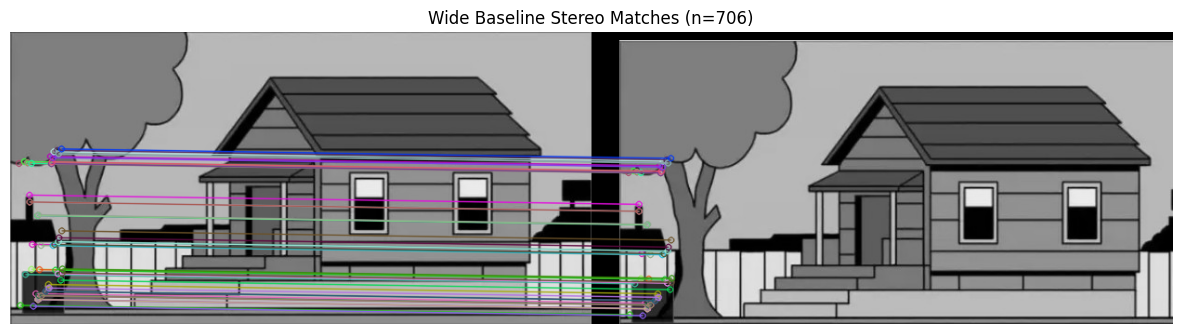

Số lượng matches: 706


In [22]:
# 10. WIDE BASE-LINE STEREO
print("\n10. WIDE BASE-LINE STEREO")

def wide_baseline_stereo(img1, img2):
    """Wide baseline stereo matching"""
    # SIFT detector
    sift = cv2.SIFT_create()
    kp1, des1 = sift.detectAndCompute(img1, None)
    kp2, des2 = sift.detectAndCompute(img2, None)
    
    # FLANN matcher
    FLANN_INDEX_KDTREE = 1
    index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
    search_params = dict(checks=50)
    flann = cv2.FlannBasedMatcher(index_params, search_params)
    
    matches = flann.knnMatch(des1, des2, k=2)
    
    # Lowe's ratio test
    good_matches = []
    for match_pair in matches:
        if len(match_pair) == 2:
            m, n = match_pair
            if m.distance < 0.7 * n.distance:
                good_matches.append(m)
    
    # Vẽ matches
    img_matches = cv2.drawMatches(img1, kp1, img2, kp2, good_matches[:50], None,
                                   flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
    
    return img_matches, len(good_matches)

# Thực hiện wide baseline stereo (sử dụng img và img2 đã được định nghĩa)
print("Thực hiện Wide baseline stereo với img và img2...")
stereo_result, n_matches = wide_baseline_stereo(cv2.cvtColor(img, cv2.COLOR_BGR2GRAY),
                                                cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY))

quan.figure(figsize=(15, 8))
quan_imshow(stereo_result, f'Wide Baseline Stereo Matches (n={n_matches})')
quan.show()

print(f"Số lượng matches: {n_matches}")



11. CONTENT-BASED IMAGE RETRIEVAL (CBIR)
Thêm ảnh vào database:
  + Đã thêm: Original
  + Đã thêm: Rotated
  + Đã thêm: Blurred
  + Đã thêm: Bright
  + Đã thêm: Dark

Tìm kiếm với query image:


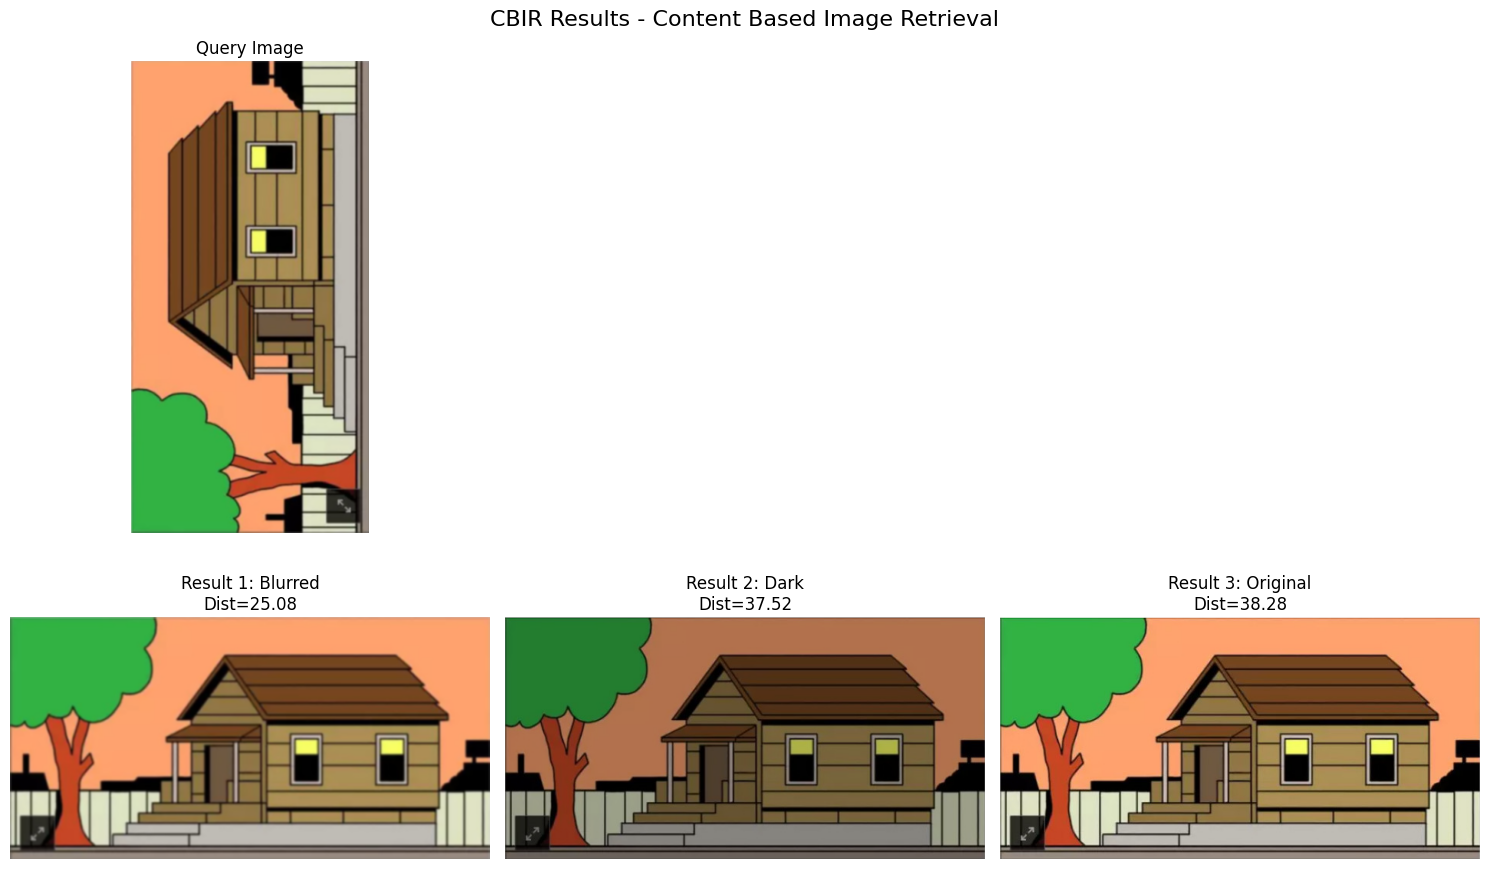

In [23]:
# 11. CBIR (CONTENT-BASED IMAGE RETRIEVAL)
print("\n11. CONTENT-BASED IMAGE RETRIEVAL (CBIR)")

class CBIR:
    """Hệ thống Content-Based Image Retrieval đơn giản"""
    
    def __init__(self):
        self.sift = cv2.SIFT_create()
        self.image_features = []
        self.image_paths = []
    
    def extract_features(self, image):
        """Trích xuất đặc trưng từ ảnh"""
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        keypoints, descriptors = self.sift.detectAndCompute(gray, None)
        
        if descriptors is None:
            return None
        
        # Tạo feature vector bằng cách tính histogram của descriptors
        feature_vector = np.mean(descriptors, axis=0)
        return feature_vector
    
    def add_image(self, image, name):
        """Thêm ảnh vào database"""
        features = self.extract_features(image)
        if features is not None:
            self.image_features.append(features)
            self.image_paths.append(name)
            return True
        return False
    
    def search(self, query_image, top_k=3):
        """Tìm kiếm ảnh tương tự"""
        query_features = self.extract_features(query_image)
        
        if query_features is None:
            return []
        
        # Tính khoảng cách Euclidean
        distances = []
        for features in self.image_features:
            dist = np.linalg.norm(query_features - features)
            distances.append(dist)
        
        # Lấy top-k kết quả
        indices = np.argsort(distances)[:top_k]
        results = [(self.image_paths[i], distances[i]) for i in indices]
        
        return results

# Khởi tạo hệ thống CBIR
cbir = CBIR()

# Thêm ảnh vào database (tạo các biến thể từ example.jpg)
print("Thêm ảnh vào database:")
variations = [
    ('Original', img),
    ('Rotated', cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)),
    ('Blurred', cv2.GaussianBlur(img, (5, 5), 0)),
    ('Bright', cv2.convertScaleAbs(img, alpha=1.2, beta=30)),
    ('Dark', cv2.convertScaleAbs(img, alpha=0.7, beta=0))
]

for name, var_img in variations:
    success = cbir.add_image(var_img, name)
    if success:
        print(f"  + Đã thêm: {name}")

# Tạo query image (một biến thể khác)
query_img = cv2.rotate(img, cv2.ROTATE_90_COUNTERCLOCKWISE)
query_img = cv2.GaussianBlur(query_img, (3, 3), 0)

# Tìm kiếm
print("\nTìm kiếm với query image:")
results = cbir.search(query_img, top_k=3)

# Hiển thị kết quả
quan.figure(figsize=(15, 10))

quan.subplot(2, 3, 1)
quan_imshow(query_img, 'Query Image')

for i, (name, distance) in enumerate(results):
    quan.subplot(2, 3, i+4)
    # Tìm ảnh tương ứng
    for n, v in variations:
        if n == name:
            quan_imshow(v, f'Result {i+1}: {name}\nDist={distance:.2f}')
            break

quan.suptitle('CBIR Results - Content Based Image Retrieval', fontsize=16)
quan.tight_layout()
quan.show()



12. BAG-OF-WORDS WITH SIFT + HISTOGRAM
Tạo các biến thể ảnh...

Xây dựng từ điển visual words...
Tổng số descriptors: 2820
K-means thành công: 8 centers
Compactness: 280065165.49

Đã xây dựng từ điển thành công!
Số lượng visual words: 8
Kích thước vocabulary: (8, 128)

Đang tính histogram cho Original...
  + Đã tính xong: Original
    Histogram: [0.21  0.067 0.181 0.162 0.087 0.074 0.122 0.097]

Đang tính histogram cho Rotated...
  + Đã tính xong: Rotated
    Histogram: [0.207 0.069 0.193 0.166 0.085 0.074 0.106 0.098]

Đang tính histogram cho Blurred...
  + Đã tính xong: Blurred
    Histogram: [0.118 0.078 0.179 0.149 0.185 0.088 0.147 0.055]


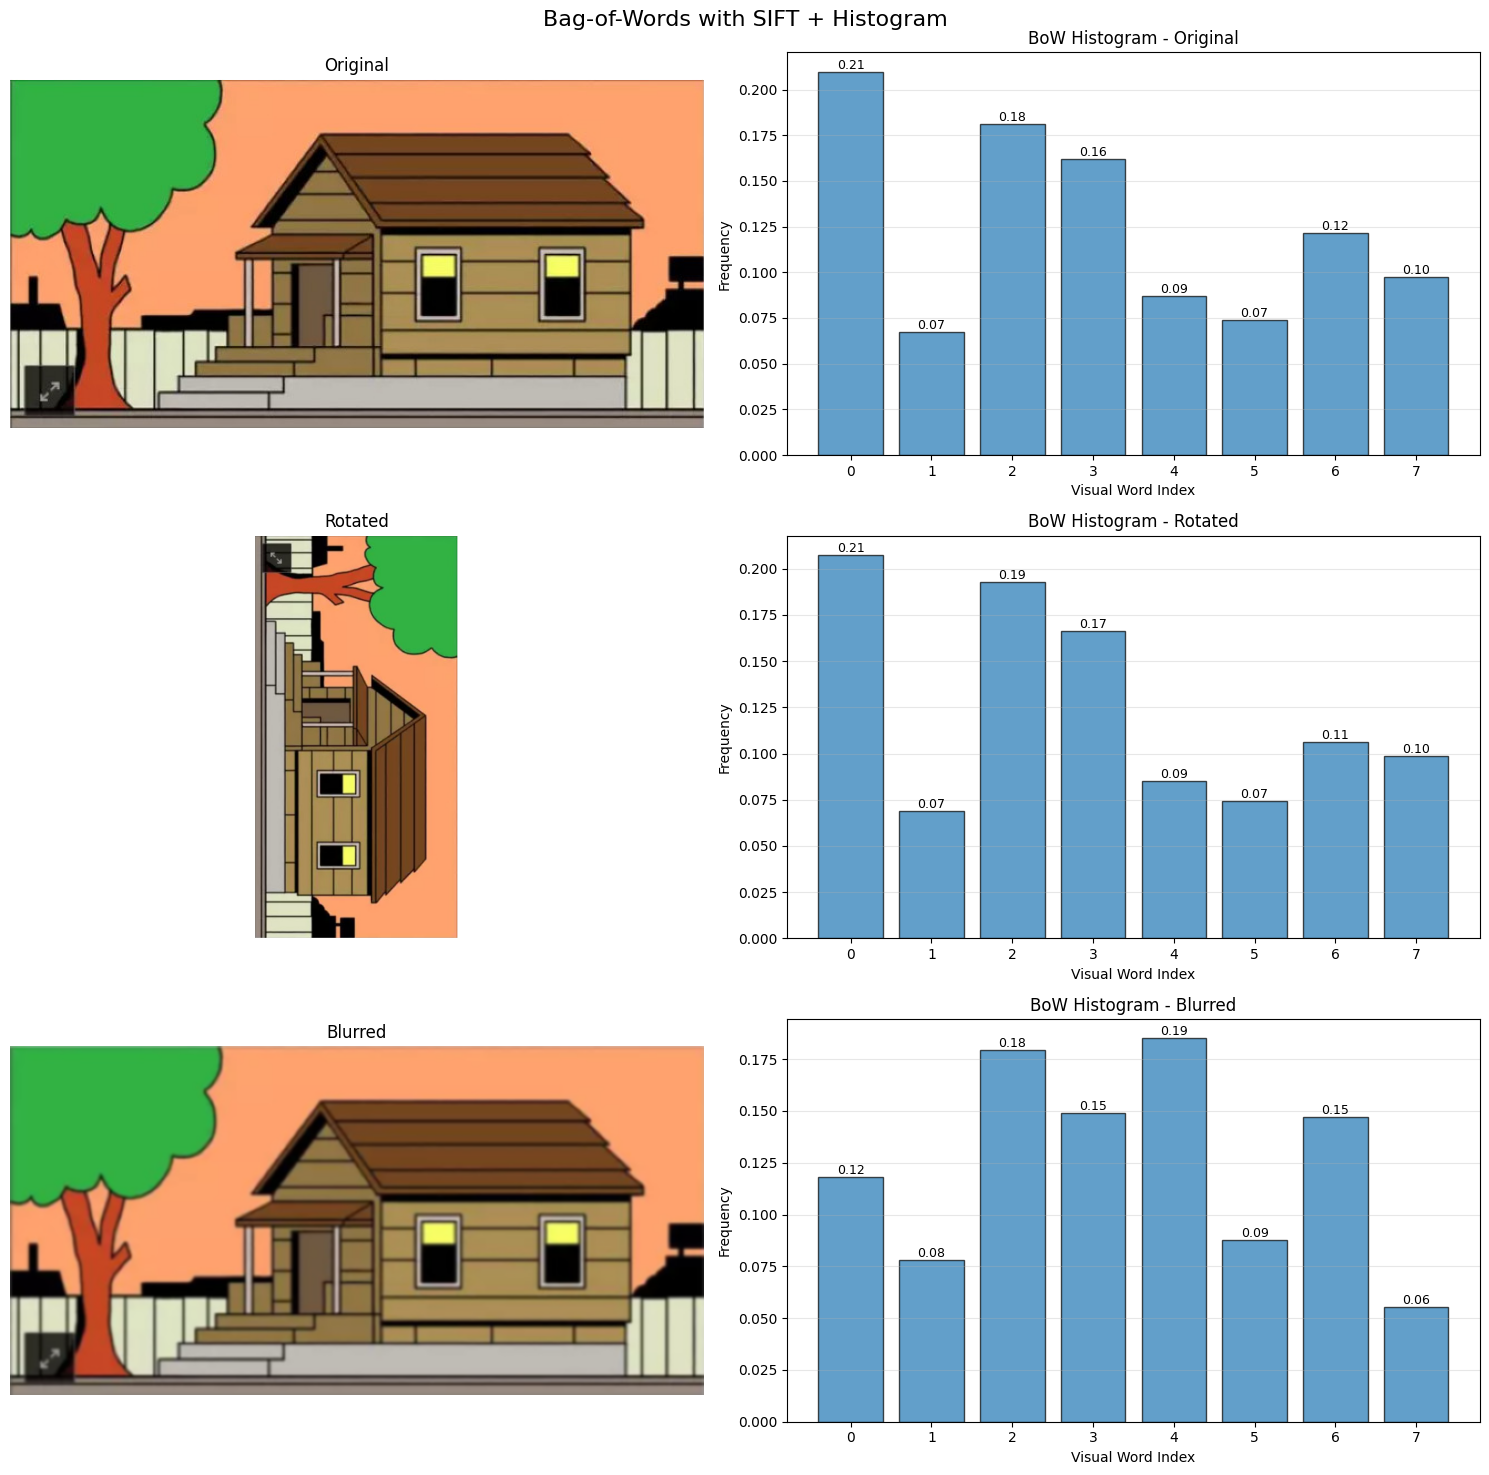

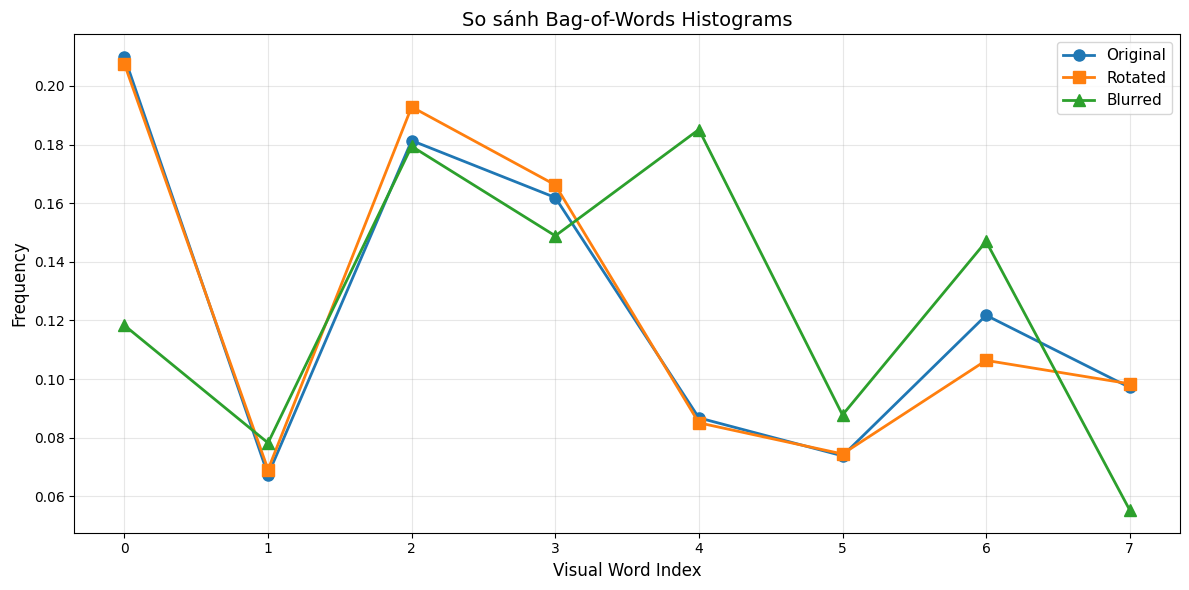


MA TRẬN TƯƠNG QUAN GIỮA CÁC ẢNH

          Original Rotated Blurred
Original   1.000   0.991   0.422
 Rotated   0.991   1.000   0.413
 Blurred   0.422   0.413   1.000

Cặp ảnh giống nhau nhất: Original - Rotated
Độ tương quan: 0.991

KẾT THÚC PHẦN 12


In [26]:
# 12. BAG-OF-WORDS WITH SIFT + HISTOGRAM
print("\n12. BAG-OF-WORDS WITH SIFT + HISTOGRAM")

class BoWWithSIFT:
    """Bag of Words với SIFT và Histogram"""
    
    def __init__(self, n_words=20):
        self.n_words = n_words
        self.sift = cv2.SIFT_create()
        self.vocabulary = None
        self.kmeans = None
    
    def build_vocabulary(self, images):
        """Xây dựng từ điển visual words từ nhiều ảnh"""
        all_descriptors = []
        
        for img in images:
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            _, descriptors = self.sift.detectAndCompute(gray, None)
            
            if descriptors is not None:
                all_descriptors.append(descriptors)
        
        if not all_descriptors:
            print("Không có descriptors nào được tìm thấy")
            return False
        
        # Gộp tất cả descriptors
        all_descriptors = np.vstack(all_descriptors)
        print(f"Tổng số descriptors: {len(all_descriptors)}")
        
        # Giảm số lượng descriptors nếu quá nhiều (để tăng tốc)
        if len(all_descriptors) > 10000:
            indices = np.random.choice(len(all_descriptors), 10000, replace=False)
            all_descriptors = all_descriptors[indices]
            print(f"Đã giảm descriptors xuống: {len(all_descriptors)}")
        
        # Đảm bảo số lượng descriptors đủ lớn
        if len(all_descriptors) < self.n_words:
            print(f"Cảnh báo: Số descriptors ({len(all_descriptors)}) < số words ({self.n_words})")
            self.n_words = len(all_descriptors)
            print(f"Đã điều chỉnh số words thành: {self.n_words}")
        
        # Áp dụng K-means
        criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 20, 0.1)
        try:
            # Chuyển đổi dữ liệu
            data = all_descriptors.astype(np.float32)
            
            # Thực hiện K-means
            compactness, labels, centers = cv2.kmeans(
                data, 
                self.n_words, 
                None, 
                criteria, 
                10, 
                cv2.KMEANS_RANDOM_CENTERS
            )
            
            # Lưu vocabulary và labels
            self.vocabulary = centers
            self.labels = labels.flatten()
            
            print(f"K-means thành công: {len(centers)} centers")
            print(f"Compactness: {compactness:.2f}")
            
            return True
            
        except Exception as e:
            print(f"Lỗi khi thực hiện K-means: {e}")
            return False
    
    def compute_histogram(self, image):
        """Tính histogram BoW cho một ảnh"""
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        keypoints, descriptors = self.sift.detectAndCompute(gray, None)
        
        if descriptors is None or self.vocabulary is None:
            print(f"  Không có descriptors hoặc vocabulary")
            return None
        
        if len(descriptors) == 0:
            print(f"  Không có keypoints")
            return None
        
        # Tạo histogram
        histogram = np.zeros(self.n_words, dtype=np.float32)
        
        # Gán mỗi descriptor vào visual word gần nhất
        for desc in descriptors:
            # Tính khoảng cách đến tất cả visual words
            distances = np.linalg.norm(self.vocabulary - desc, axis=1)
            word_idx = np.argmin(distances)
            
            # Đảm bảo index hợp lệ
            if 0 <= word_idx < self.n_words:
                histogram[word_idx] += 1
        
        # Chuẩn hóa histogram
        total = np.sum(histogram)
        if total > 0:
            histogram = histogram / total
        
        return histogram

# Tạo variations với số lượng ít hơn
print("Tạo các biến thể ảnh...")
variations_simple = [
    ('Original', img),
    ('Rotated', cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)),
    ('Blurred', cv2.GaussianBlur(img, (5, 5), 0))
]

# Khởi tạo và xây dựng từ điển
print("\nXây dựng từ điển visual words...")
bow = BoWWithSIFT(n_words=8)  # Sử dụng 8 words
image_list = [img] + [v for _, v in variations_simple]

success = bow.build_vocabulary(image_list)

if success:
    print("\nĐã xây dựng từ điển thành công!")
    print(f"Số lượng visual words: {bow.n_words}")
    print(f"Kích thước vocabulary: {bow.vocabulary.shape}")
    
    # Tính histogram cho từng ảnh
    histograms = []
    for name, var_img in variations_simple:
        print(f"\nĐang tính histogram cho {name}...")
        hist = bow.compute_histogram(var_img)
        if hist is not None:
            histograms.append((name, hist))
            print(f"  + Đã tính xong: {name}")
            print(f"    Histogram: {hist.round(3)}")
        else:
            print(f"  - Không tính được histogram cho {name}")
    
    # Hiển thị kết quả
    if histograms:
        n_imgs = len(histograms)
        quan.figure(figsize=(15, 5 * n_imgs))
        
        for idx, (name, hist) in enumerate(histograms):
            # Hiển thị ảnh
            quan.subplot(n_imgs, 2, 2*idx + 1)
            for n, v in variations_simple:
                if n == name:
                    quan_imshow(v, f'{name}')
                    break
            
            # Hiển thị histogram
            quan.subplot(n_imgs, 2, 2*idx + 2)
            x = np.arange(len(hist))
            bars = quan.bar(x, hist, edgecolor='black', alpha=0.7)
            
            # Thêm giá trị lên đầu cột
            for bar, val in zip(bars, hist):
                height = bar.get_height()
                quan.text(bar.get_x() + bar.get_width()/2., height,
                         f'{val:.2f}', ha='center', va='bottom', fontsize=9)
            
            quan.title(f'BoW Histogram - {name}')
            quan.xlabel('Visual Word Index')
            quan.ylabel('Frequency')
            quan.xticks(x)
            quan.grid(True, alpha=0.3, axis='y')
        
        quan.suptitle('Bag-of-Words with SIFT + Histogram', fontsize=16)
        quan.tight_layout()
        quan.show()
        
        # Vẽ biểu đồ so sánh
        if len(histograms) >= 2:
            quan.figure(figsize=(12, 6))
            
            # Vẽ tất cả histograms trên cùng một đồ thị
            markers = ['o', 's', '^', 'D', 'v']
            for i, (name, hist) in enumerate(histograms):
                quan.plot(range(len(hist)), hist, 
                         marker=markers[i % len(markers)], 
                         linewidth=2, 
                         markersize=8,
                         label=name)
            
            quan.title('So sánh Bag-of-Words Histograms', fontsize=14)
            quan.xlabel('Visual Word Index', fontsize=12)
            quan.ylabel('Frequency', fontsize=12)
            quan.legend(fontsize=11)
            quan.grid(True, alpha=0.3)
            quan.xticks(range(len(histograms[0][1])))
            quan.tight_layout()
            quan.show()
            
            # Tính ma trận tương quan
            print("\n" + "="*50)
            print("MA TRẬN TƯƠNG QUAN GIỮA CÁC ẢNH")
            print("="*50)
            
            n = len(histograms)
            corr_matrix = np.zeros((n, n))
            
            for i in range(n):
                for j in range(n):
                    if i <= j:  # Chỉ tính upper triangle
                        hist1 = histograms[i][1]
                        hist2 = histograms[j][1]
                        corr = np.corrcoef(hist1, hist2)[0, 1]
                        corr_matrix[i, j] = corr
                        corr_matrix[j, i] = corr
            
            # In ma trận
            print("\n", end="")
            print("          ", end="")
            for name, _ in histograms:
                print(f"{name[:8]:>8}", end="")
            print()
            
            for i in range(n):
                print(f"{histograms[i][0][:8]:>8}", end="")
                for j in range(n):
                    print(f"{corr_matrix[i, j]:8.3f}", end="")
                print()
            
            # Tìm cặp ảnh giống nhau nhất
            max_corr = -1
            max_pair = None
            for i in range(n):
                for j in range(i+1, n):
                    if corr_matrix[i, j] > max_corr:
                        max_corr = corr_matrix[i, j]
                        max_pair = (histograms[i][0], histograms[j][0])
            
            if max_pair:
                print(f"\nCặp ảnh giống nhau nhất: {max_pair[0]} - {max_pair[1]}")
                print(f"Độ tương quan: {max_corr:.3f}")
    
    else:
        print("\nKhông có histogram nào được tính toán")
        
        # Debug: Kiểm tra descriptors
        print("\nDebug thông tin:")
        for name, var_img in variations_simple:
            gray = cv2.cvtColor(var_img, cv2.COLOR_BGR2GRAY)
            kp, des = cv2.SIFT_create().detectAndCompute(gray, None)
            if des is not None:
                print(f"  {name}: {len(kp)} keypoints, {des.shape} descriptors")
            else:
                print(f"  {name}: Không có descriptors")
else:
    print("\nKhông thể xây dựng từ điển visual words")
    
    # Thử với tham số khác
    print("\nThử lại với số words nhỏ hơn...")
    bow = BoWWithSIFT(n_words=5)
    if bow.build_vocabulary(image_list):
        print("Thành công với n_words=5!")
    else:
        print("Vẫn không thành công. Kiểm tra lại ảnh đầu vào.")

print("\n" + "="*50)
print("KẾT THÚC PHẦN 12")
print("="*50)